In [1]:
# In Class Solution to Example 6.2

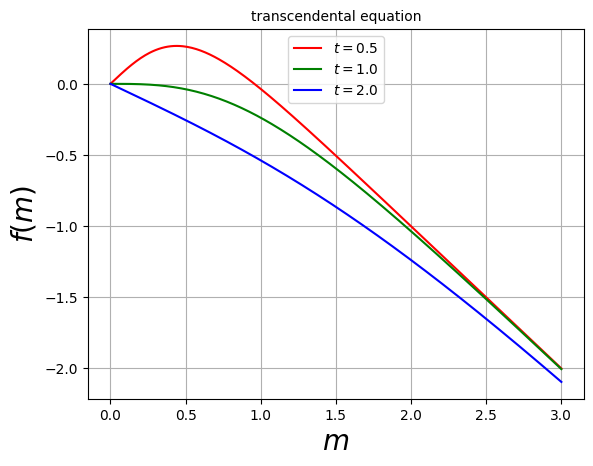

In [9]:
# Copy graphing and solution from bisection
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

# Now plot! Don't forget the different labels! 
fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'$m$', fontsize=20) # set the x label
ax.set_ylabel(r'$f(m)$', fontsize=20) # set the y label. Note that the 'r' is necessary to remove the need for double slashes. You can use LaTeX! 
ax.set_title(r'transcendental equation', fontsize=10) # set the title 

# construct the variable: 
m = np.linspace(0,3,300)

# calculate f(m,t) at t=0.5, 1.0, 2.0
tvals = [0.5, 1.0, 2.0]
fvals = [f(m,t) for t in tvals] # note that fvals will be a list of numpy arrays at this point

# make a one-dimensional plot for each value of t
colors = ['red', 'green', 'blue']
linestyles = ['-','--','-.']
for i,t in enumerate(tvals):
    ax.plot(m, fvals[i], label=r'$t=' + str(t) + '$', ls='-', color=colors[i])
    
# construct the legend:
ax.legend(loc='upper center')  # Add a legend

ax.grid() # show the grid. 

plt.show() # show the plot here


In [6]:
# Start by defining the function, in the form f(m) = 0:
import numpy as np
import math

def f(m,t): 
    """Transcendental equation for the reduced magnetization at reduced temperature t"""
    return np.tanh(m/t) - m

# The bisection algorithm: 
# func should be a function for which we are trying to find the solution, in the form f(x)=0
# xmin and xmax should enclose the root (the function must change signs from xmin to xmax)
# Nmax is the number of evaluations
# prec is the required precision
def bisection(func, xmin, xmax, Nmax, prec): 
    """Function that implements the bisection algorithm for root finding"""
    n = 0 # number of steps taken
    val = 1E99 # the value of the equation, initialize to a large number
    root = math.nan # initialize the root to "not a number"
    while abs(val) > prec and n < Nmax: # loop terminates either when the max number of evals is reached or the precision is reached
        # get the equation values at the edges [xmin, xmax], 
        # and at the bisection point: 
        val = func((xmin+xmax)/2)
        valmax = func(xmax)
        valmin = func(xmin)
        # figure out in which of the two intervals there's a sign change:
        if val * valmax < 0: # sign change between bisection-xmax, set minimum to bisection
            xmin = (xmin+xmax)/2
        elif val * valmin < 0: # sign change between xmin-bisection, set max to bisection
            xmax = (xmin+xmax)/2
        n = n + 1
    if n > Nmax-1:
        print("Warning: maximum number of evaluations exceeded:", Nmax)
    root = (xmin+xmax)/2
    return root, n


# let's try it out on the function with t=0.5
# we can use a partial function to fix the parameter:
# See chapter 4 for more details
from functools import partial # partial functions allow us to fix a certain number of arguments of a function and generate a new function.
ft05 = partial(f, t=0.5) # this has created a new function with the parameter t fixed

# launch the bisection in [0.5, 1.5] for a precision of 1E-6 and 1000 maximum evals:
maxiterations = 40
xmin = 0.5
xmax = 1.5
precision = 1E-10
m05, niter = bisection(ft05, xmin, xmax, maxiterations, precision)
xBS = m05
print("Root for t=0.5 using bisection:", m05, 'after', niter,'iterations')


Root for t=0.5 using bisection: 0.957504024147056 after 32 iterations


In [12]:
# copy the forward difference derivative from example 4.6

# Re-define functions to be used in this notebook:
# define a function for the forward-difference derivative.
def dfdx_FD(func, x, h):
    """Calculates the forward-difference derivative of a function func at t, with step size h"""
    return (func(x+h) - func(x))/h

# write the Newton-Raphson root finding function: 
def NewtonRaphson(func, x0, prec, Nmax, h=1E-5):
    """Implements the Newton-Raphson method"""
    Nsteps = 0
    while Nsteps < Nmax and abs(func(x0)) > prec:
        # update the trial:
        x0 = x0 - func(x0)/dfdx_FD(func,x0,h)
        Nsteps += 1
    return x0, Nsteps


xNR, NNR = NewtonRaphson(ft05, xBS, precision, maxiterations)
print('Testing Newton-Raphson=', xNR, 'arter', NNR, 'steps')

# do the same without knowing the precise answer
xNR, NNR = NewtonRaphson(ft05, 0.9, precision, maxiterations)
print('Actual Newton-Raphson=', xNR, 'arter', NNR, 'steps')


Testing Newton-Raphson= 0.957504024147056 arter 0 steps
Actual Newton-Raphson= 0.9575040240809918 arter 3 steps
